In [1]:
import os
import fnmatch
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import numpy as np

/tmp/ipykernel_47716/3601556291.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [8]:
pocket_dir = "/home/alex/sshfs_mountpoints/mdpocket_oversized/"

target_pockets = [
    # dynid, trajid, pocketid
    ('187', '11733', '10'),
    ('187', '11733', '21')
]

In [ ]:
# Old example
# pocket_dir = "/home/alex/sshfs_mountpoints/mdpocket_oversized/"

# target_pockets = [
#     # dynid, trajid, pocketid
#     ('11', '10185', '0'),
#     ('11', '10185', '2'),
#     ('11', '10185', '3'),
#     ('11', '10185', '4'),
#     ('11', '10185', '5'),
#     ('11', '10185', '7'),
#     ('11', '10185', '8'),
#     ('11', '10185', '9'),
#     ('11', '10185', '10'),
#     ('11', '10185', '11')
# ]

In [ ]:
def read_descriptors_file(file_path):
    """
    Read a tab-separated file and return a dictionary where each key is a
    column name and each value is a list of column values.

    Args:
        file_path (str): Path to the tab-separated file.

    Returns:
        dict: A dictionary with column names as keys and lists of values as
        values.
    """
    values = {}
    fh = open(file_path, 'r')

    # Read the header line and initialize the values dictionary
    header = fh.readline()
    for field in header.split():
        values[field] = []
    
    # Read the rest of the file and populate the values dictionary
    for line in fh:
        fields = line.split()
        for i, field in enumerate(header.split()):
            values[field].append(fields[i])

    fh.close()
    return values


def moving_average(data, window_size):
    """
    Calculate the moving average of a list of numbers.

    Args:
        data (list): List of numbers.
        window_size (int): Size of the moving average window.

    Returns:
        list: List of moving averages.
    """
    if not data or window_size <= 0:
        return []

    cumsum = [0] * (len(data) + 1)
    for i, x in enumerate(data):
        cumsum[i + 1] = cumsum[i] + x

    return [(cumsum[i + window_size] - cumsum[i]) / window_size
            for i in range(len(data) - window_size + 1)]


def find(pattern, path):
    """
    Find all files matching a given pattern in a directory and its
    subdirectories.

    Args:
        pattern (str): The pattern to match files against.
        path (str): The directory path to search in.
    Returns:
        generator: A generator yielding paths of files that match the pattern.
    """
    for root, dirs, files in os.walk(path):
        for name in files:
            if fnmatch.fnmatch(name, pattern):
                yield os.path.join(root, name)


def extract_ids(path):
    """
    Extracts trajectory ID, dynID, and pocket ID from a given file path.
    pocket_dir = "/home/alex/sshfs_mountpoints/mdpocket_oversized/"

target_pockets = [
    # dynid, trajid, pocketid
    ('11', '10185', '0'),
    ('11', '10185', '2'),
    ('11', '10185', '3'),
    ('11', '10185', '4'),
    ('11', '10185', '5'),
    ('11', '10185', '7'),
    ('11', '10185', '8'),
    ('11', '10185', '9'),
    ('11', '10185', '10'),
    ('11', '10185', '11')
]
    Parameters:
        path (str): The full file path.
        
    Returns:
        dict: A dictionary with keys 'trajectory_id', 'dyn_id', and 'pocket_id'.
    """
    # Match descriptorPockets_<traj_id>_trj_<dyn_id>.xtc
    trajectory_match = re.search(r'descriptorPockets_(\d+)_trj_(\d+)\.xtc', path)
    # Match pocket_num_<pocket_id>_descriptors.txt
    pocket_match = re.search(r'pocket_num_(\d+)_descriptors\.txt', path)

    if trajectory_match and pocket_match:
        traj_id = trajectory_match.group(1)
        dyn_id = trajectory_match.group(2)
        pocket_id = pocket_match.group(1)

        return (traj_id, dyn_id, pocket_id)
    else:
        print(f"Could not extract all required IDs from the path: {path}.")
        return None, None, None


def plot_volumes(dynid, trajid, pocketid, window_size=20):
    """
    Plot the smoothed volume of a pocket over time.
    Args:
        dynid (int): The dynamic ID of the trajectory.
        trajid (int): The trajectory ID.
        pocketid (int): The pocket ID.
        window_size (int): The size of the moving average window.
    """
    file = os.path.join(pocket_dir, f"{trajid}_trj_{dynid}.xtc_mdpocket/descriptorPockets_{trajid}_trj_{dynid}.xtc/pocket_num_{pocketid}_descriptors.txt")
    values_dict = read_descriptors_file(file)
    volumes = list(map(float, values_dict['pock_volume'])) # Convert to float
    smoothed_volume = moving_average(volumes, window_size=window_size)
    plt.xlabel('Time (ns)')
    plt.ylabel('Volume (A³)')
    plt.plot(smoothed_volume)
    

def plot_multiple_volumes(list_of_ids, window_size=20):
    """
    Plot the smoothed volumes of multiple pockets over time.
    
    Args:
        list_of_ids (list): List of tuples containing (dynid, trajid, pocketid).
        window_size (int): The size of the moving average window.
    """
    for dynid, trajid, pocketid in list_of_ids:
        plot_volumes(dynid, trajid, pocketid, window_size=window_size)
    
    plt.xlabel('Time (ns)')
    plt.ylabel('Volume (A³)')
    # plt.title('Pocket Volumes Over Time')
    # plt.legend([f'Dyn {dynid}, Traj {trajid}, Pocket {pocketid}' for dynid, trajid, pocketid in list_of_ids])
    plt.show()



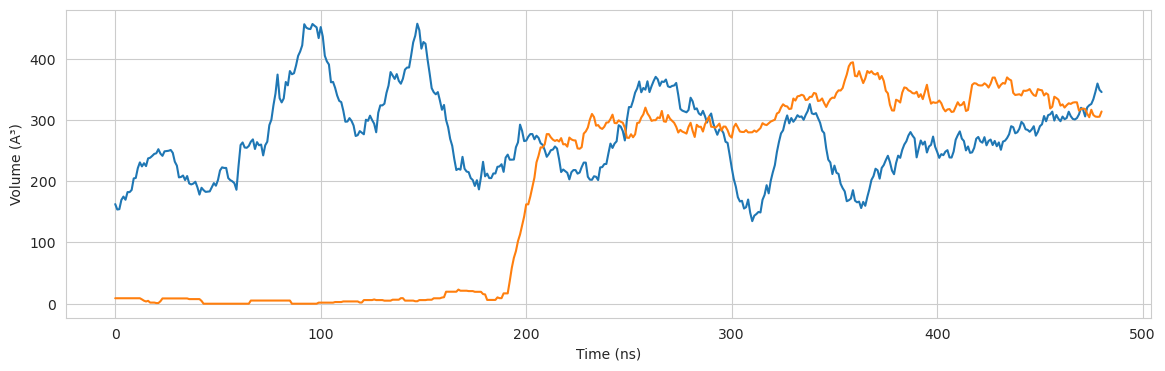

In [10]:
plt.figure(figsize=(14, 4))
sns.set_style("whitegrid")

for dynid, trajid, pocketid in target_pockets:
    plot_volumes(dynid, trajid, pocketid, window_size=20)

plt.xlabel('Time (ns)')
plt.ylabel('Volume (A³)')
# plt.show()
plt.savefig("/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/07_tool_description/02_volumes_plots/pocket_volumes_dyn187_traj11733.svg")

# plot_multiple_volumes(target_pockets, window_size=20)
